Import Package

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.patches as mpatches


In [5]:
# Open the dataset named 'df_all_sectioncode(2020-2024).csv'
import pandas as pd
df = pd.read_csv(r'D:/Rutgers/Courses/2025spring/1_1430-1720_Visualization/Project/DATAWEB - NEW/df_all_sectioncode(2020-2024).csv')

In [93]:
# Check the basic information of original dataset
print(df.head())
df.info()

   Data Type      Country  Year  HTS Number  \
0  FAS Value  Afghanistan  2020          94   
1  FAS Value  Afghanistan  2020          82   
2  FAS Value  Afghanistan  2020          84   
3  FAS Value  Afghanistan  2020          82   
4  FAS Value  Afghanistan  2020          82   

                                         Description        District   Value  \
0  FURNITURE; BEDDING, CUSHIONS ETC.; LAMPS AND L...  Washington, DC   35341   
1  TOOLS, IMPLEMENTS, CUTLERY, SPOONS AND FORKS, ...   Cleveland, OH  631593   
2  NUCLEAR REACTORS, BOILERS, MACHINERY AND MECHA...   Charlotte, NC    4250   
3  TOOLS, IMPLEMENTS, CUTLERY, SPOONS AND FORKS, ...     Chicago, IL  465151   
4  TOOLS, IMPLEMENTS, CUTLERY, SPOONS AND FORKS, ...  Charleston, SC    3637   

              Flow  Section  
0  DomesticExports       20  
1  DomesticExports       15  
2  DomesticExports       16  
3  DomesticExports       15  
4  DomesticExports       15  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179366

In [61]:
# The unique values in column 'Flow'
df['Flow'].unique()

array(['DomesticExports', 'ForeignExports', 'GeneralImports'],
      dtype=object)

In [62]:
# The unique values in column 'Year'
df['Year'].unique()

array([2020, 2021, 2022, 2023, 2024], dtype=int64)

In [18]:
# The unique values in column 'District'
len(df['District'].unique())

df['District'].unique()



array(['Washington, DC', 'Cleveland, OH', 'Charlotte, NC', 'Chicago, IL',
       'Charleston, SC', 'Baltimore, MD', 'San Francisco, CA',
       'Los Angeles, CA', 'New Orleans, LA', 'New York, NY',
       'Savannah, GA', 'Dallas-Fort Worth, TX', 'Boston, MA',
       'Houston-Galveston, TX', 'Philadelphia, PA', 'Seattle, WA',
       'Norfolk, VA', 'St. Albans, VT', 'San Diego, CA', 'Tampa, FL',
       'Columbia-Snake, OR', 'Mobile, AL', 'Miami, FL', 'Detroit, MI',
       'El Paso, TX', 'Mail shipments (exports only)', 'Great Falls, MT',
       'Nogales, AZ', 'Anchorage, AK', 'Laredo, TX',
       'Low-valued imports and exports', 'Port Arthur, TX',
       'Minneapolis, MN', 'Portland, ME', 'San Juan, PR', 'Buffalo, NY',
       'Ogdensburg, NY', 'Duluth, MN', 'Honolulu, HI', 'Providence, RI',
       'Virgin Islands of the United States', 'Milwaukee, WI',
       'St. Louis, MO',
       'Norfolk, VA - Charleston, SC - Mobile, AL (Value of Exports of Bituminous Coal)',
       'Pembina, ND',


Build Directed Network Graph

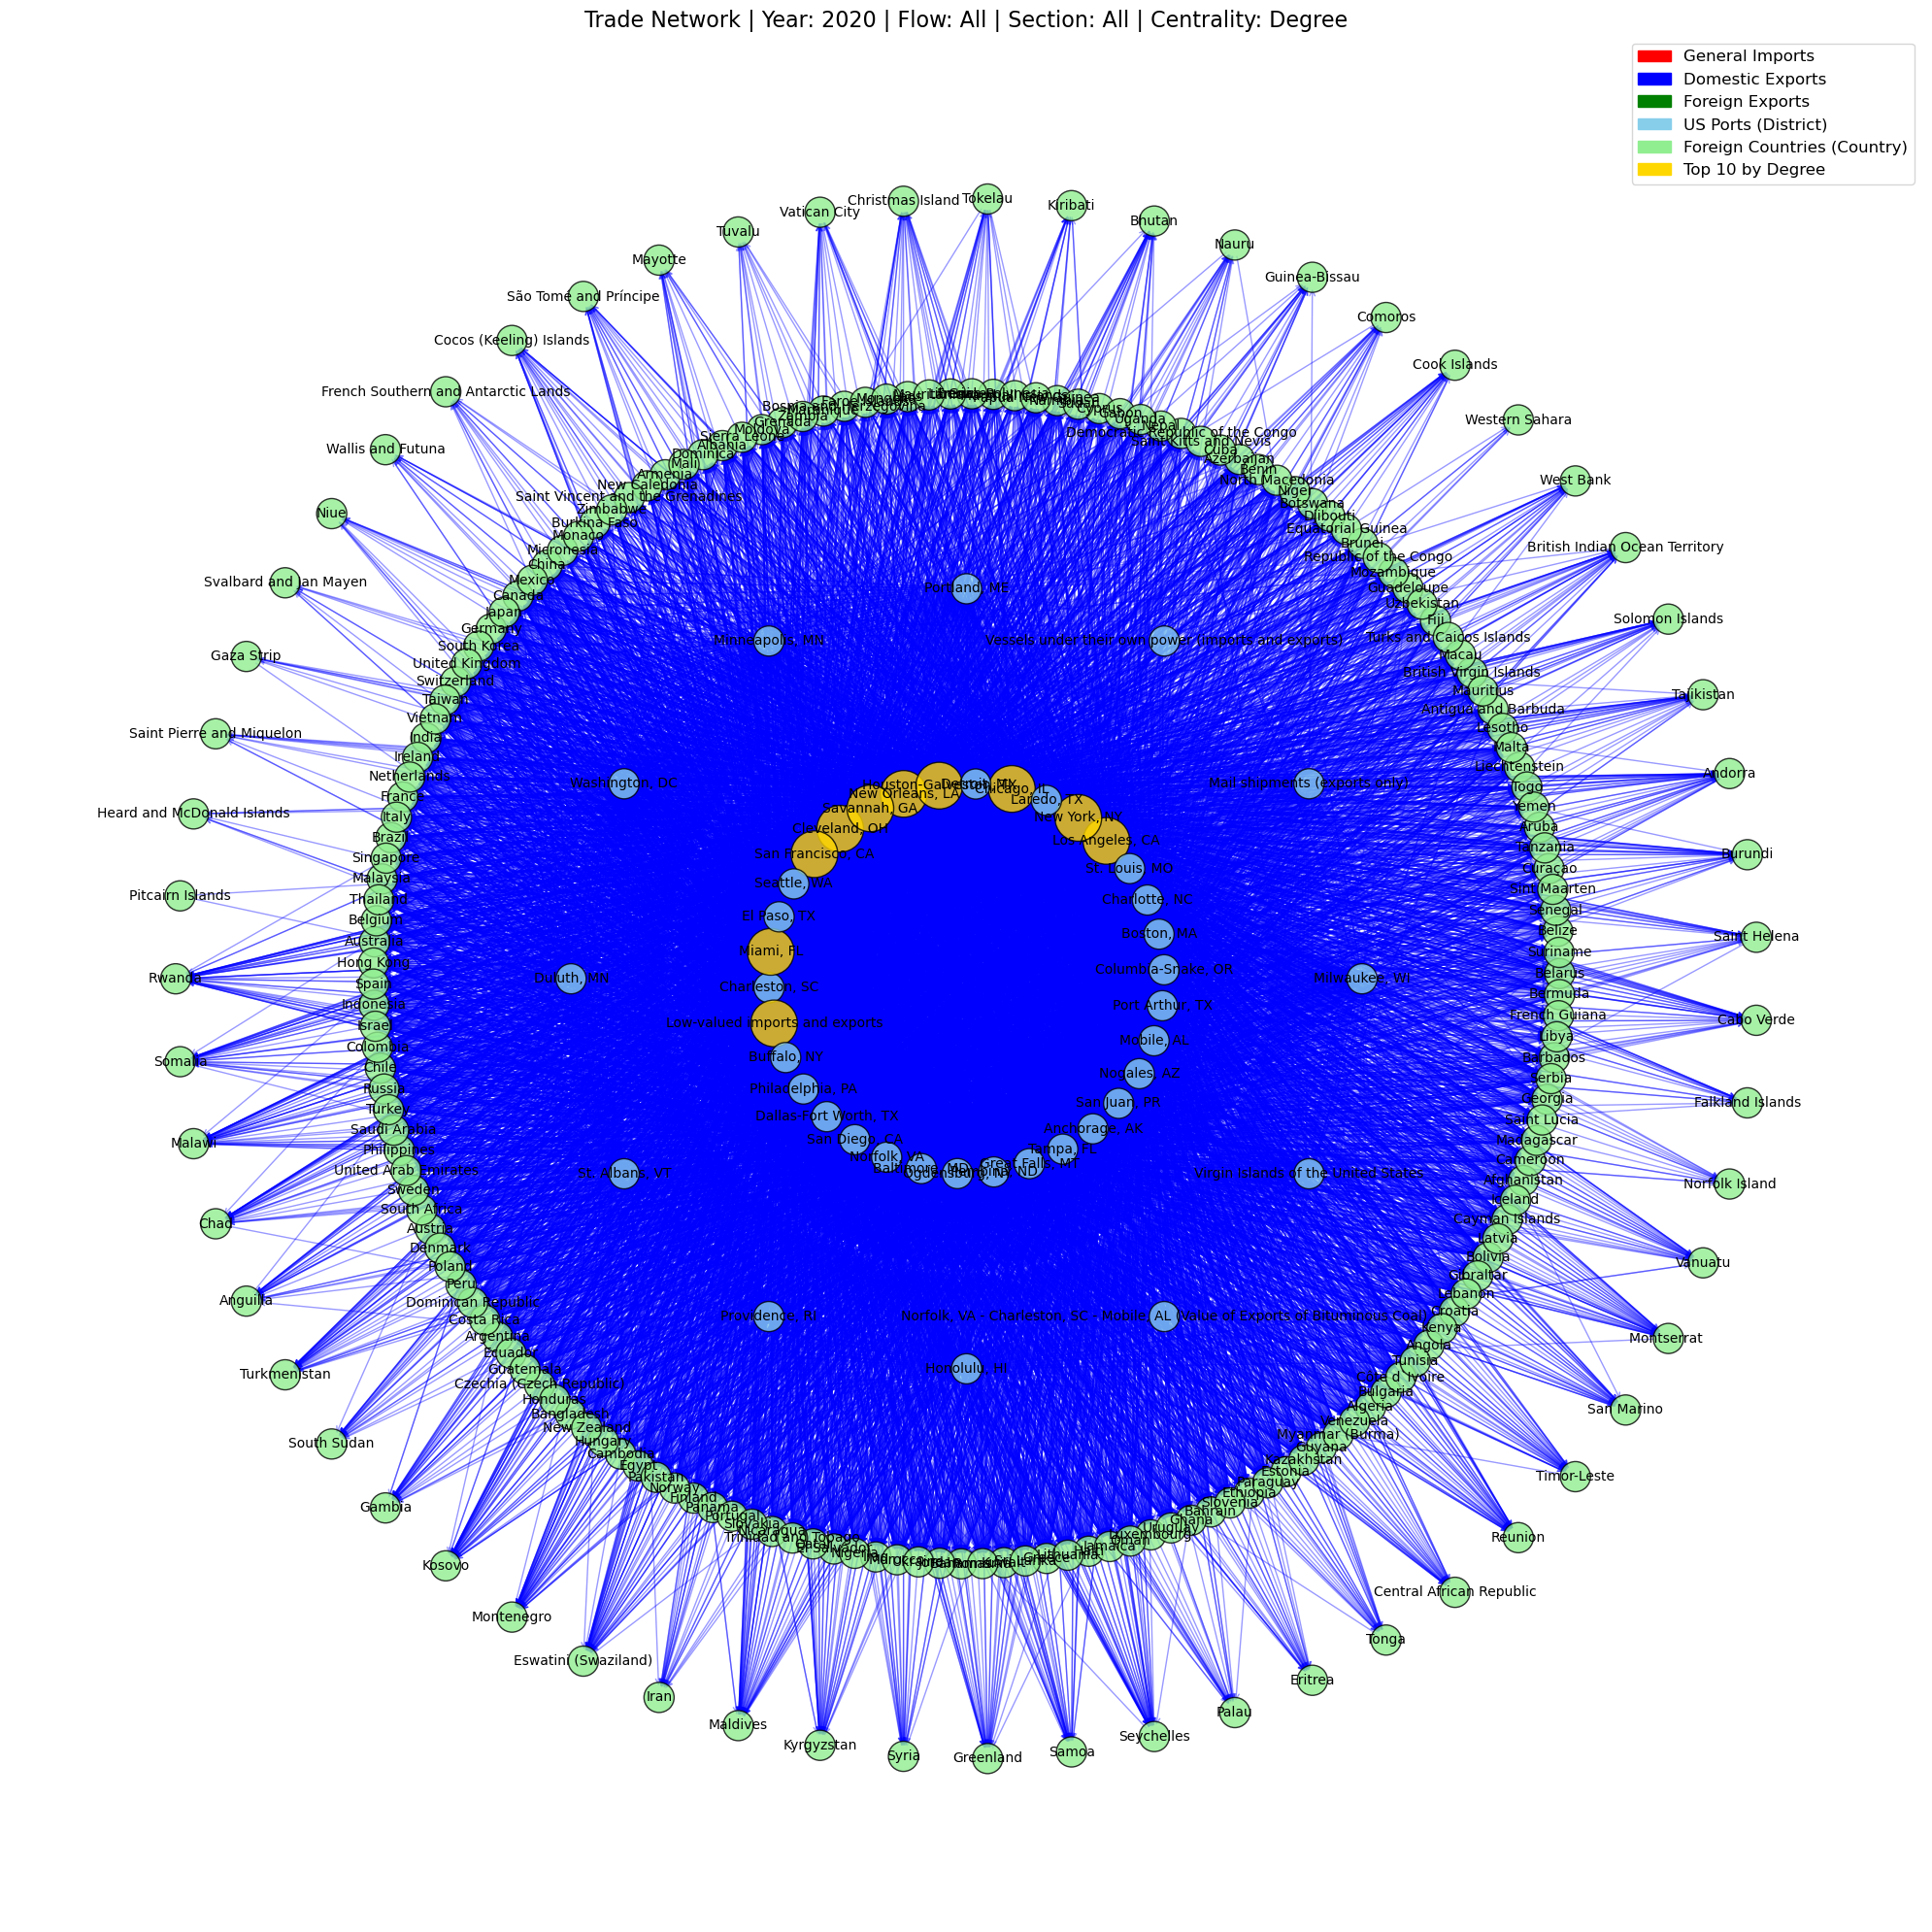

✅ Edge list exported to network_edges_2020_All_All.csv


In [65]:
# Widget：'Year' (Single Select)
year_options = sorted(df['Year'].dropna().unique())
year_dropdown = widgets.Dropdown(options=year_options, description='Year:')

# Widget：'Flow' (Single Select, with 'All'）
flow_options = ['All'] + ['GeneralImports', 'DomesticExports', 'ForeignExports']
flow_dropdown = widgets.Dropdown(options=flow_options, description='Flow:')

# Widget：'Section' (Single Select, with 'All'）
section_options = ['All'] + sorted(df['Section'].dropna().unique().astype(int).tolist())
section_dropdown = widgets.Dropdown(options=section_options, description='Section:')

# Widget：Centrality (Single Select)
centrality_dropdown = widgets.Dropdown(
    options=['Degree', 'Betweenness', 'Closeness', 'PageRank'],
    description='Centrality:'
)

# Color mapping for flow types
color_map = {
    'GeneralImports': 'red',
    'DomesticExports': 'blue',
    'ForeignExports': 'green',  
}

# Main plot function
def draw_filtered_network(year, flow_type, section, centrality_metric):
    clear_output(wait=True)
    display(widgets.HBox([year_dropdown, flow_dropdown, section_dropdown, centrality_dropdown]))

    # Step 1: Filter by Year, Flow, Section
    df_filtered = df[df['Year'] == year]
    if flow_type != 'All':
        df_filtered = df_filtered[df_filtered['Flow'] == flow_type]
    if section != 'All':
        df_filtered = df_filtered[df_filtered['Section'] == section]
    
    # Step 2: Filter valid Flow types only
    valid_flows = ['GeneralImports', 'DomesticExports', 'ForeignExports']
    df_filtered = df_filtered[df_filtered['Flow'].isin(valid_flows)]
    
    if df_filtered.empty:
        print("No data available for selected filters.")
        return

    # Step 3: Build directed graph
    G = nx.DiGraph()
    edge_colors = []
    edge_list = []
    
    for _, row in df_filtered.iterrows():
        flow = row['Flow']
        weight = row['Value']
        color = color_map.get(flow, 'gray')

        # Set direction based on flow type
        if flow == 'GeneralImports':
            source = row['Country']
            target = row['District']
        elif flow in ['DomesticExports', 'ForeignExports']:
            source = row['District']
            target = row['Country']
        else:
            # Fallback if unknown flow
            source = row['District']
            target = row['Country']
            continue

        G.add_edge(source, target, weight=weight)
        edge_colors.append(color)

    if G.number_of_edges() == 0:
        print("No edges to display for selected filters.")
        return

    # Compute Centrality
    if centrality_metric == 'Degree':
        centrality = nx.degree_centrality(G)
    elif centrality_metric == 'Betweenness':
        centrality = nx.betweenness_centrality(G, weight='weight')
    elif centrality_metric == 'Closeness':
        centrality = nx.closeness_centrality(G)
    else:
        centrality = nx.pagerank(G, weight='weight')

    top_10_nodes = sorted(centrality, key=centrality.get, reverse=True)[:10]

    # Layout shell layers
    us_total = df_filtered.groupby('District')['Value'].sum().sort_values(ascending=False)
    foreign_total = df_filtered.groupby('Country')['Value'].sum().sort_values(ascending=False)

    core_us = us_total.head(int(len(us_total) * 0.75)).index.tolist()
    other_us = us_total.tail(len(us_total) - len(core_us)).index.tolist()

    core_foreign = foreign_total.head(int(len(foreign_total) * 0.75)).index.tolist()
    other_foreign = foreign_total.tail(len(foreign_total) - len(core_foreign)).index.tolist()

    shells = [[n for n in group if n in G.nodes] for group in [core_us, other_us, core_foreign, other_foreign]]
    pos = nx.shell_layout(G, nlist=shells)

    # Draw
    plt.figure(figsize=(20, 20))
    node_colors = []
    node_sizes = []
    for node in G.nodes:
        if node in top_10_nodes:
            node_colors.append('gold')
            node_sizes.append(1200)
        elif node in df['District'].unique():
            node_colors.append('skyblue')
            node_sizes.append(500)
        else:
            node_colors.append('lightgreen')
            node_sizes.append(500)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, arrows=True, arrowstyle='->', arrowsize=10, alpha=0.4)
    nx.draw_networkx_labels(G, pos, font_size=10)

    # Legend
    legend_elements = [
        mpatches.Patch(color='red', label='General Imports'),
        mpatches.Patch(color='blue', label='Domestic Exports'),
        mpatches.Patch(color='green', label='Foreign Exports'),
        mpatches.Patch(color='skyblue', label='US Ports (District)'),
        mpatches.Patch(color='lightgreen', label='Foreign Countries (Country)'),
        mpatches.Patch(color='gold', label=f'Top 10 by {centrality_metric}')
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=12)
    plt.title(f"Trade Network | Year: {year} | Flow: {flow_type} | Section: {section} | Centrality: {centrality_metric}", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Export to CSV
    edge_df = pd.DataFrame(edge_list)
    filename = f"network_edges_{year}_{flow_type}_{section}.csv".replace(" ", "_")
    edge_df.to_csv(filename, index=False)
    print(f"✅ Edge list exported to {filename}")


# Control update handler
def update_graph(change=None):
    draw_filtered_network(year_dropdown.value, flow_dropdown.value, section_dropdown.value, centrality_dropdown.value)

# Link events
year_dropdown.observe(update_graph, names='value')
flow_dropdown.observe(update_graph, names='value')
section_dropdown.observe(update_graph, names='value')
centrality_dropdown.observe(update_graph, names='value')

# Initial display
display(widgets.HBox([year_dropdown, flow_dropdown, section_dropdown, centrality_dropdown]))
draw_filtered_network(year_dropdown.value, flow_dropdown.value, section_dropdown.value, centrality_dropdown.value)



Output the Top 10 results with Centrality

In [64]:
# Prepare centrality calculation function

def compute_centrality(G, metric):
    if metric == 'Degree':
        return nx.degree_centrality(G)
    elif metric == 'Betweenness':
        return nx.betweenness_centrality(G, weight='weight')
    elif metric == 'Closeness':
        return nx.closeness_centrality(G)
    elif metric == 'PageRank':
        return nx.pagerank(G, weight='weight')
    else:
        raise ValueError(f"Unknown centrality metric: {metric}")

# Widgets
year_dropdown = widgets.Dropdown(
    options=sorted(df['Year'].dropna().unique()),
    description='Year:'
)

flow_dropdown = widgets.Dropdown(
    options=['All', 'GeneralImports', 'DomesticExports', 'ForeignExports'],
    description='Flow:'
)

section_dropdown = widgets.Dropdown(
    options=['All'] + sorted(df['Section'].dropna().unique().astype(int).tolist()),
    description='Section:'
)

centrality_dropdown = widgets.Dropdown(
    options=['Degree', 'Betweenness', 'Closeness', 'PageRank'],
    description='Metric:'
)

# Display function

def display_top_centrality(year, flow, section, metric):
    clear_output(wait=True)
    display(widgets.HBox([year_dropdown, flow_dropdown, section_dropdown, centrality_dropdown]))
    
    # Filter data by year, flow, and section
    df_filtered = df[df['Year'] == year]
    if flow != 'All':
        df_filtered = df_filtered[df_filtered['Flow'] == flow]
    if section != 'All':
        df_filtered = df_filtered[df_filtered['Section'] == int(section)]
    
    if df_filtered.empty:
        print(f"⚠️ No data available for Year: {year}, Flow: {flow}, Section: {section}.")
        return

    # Build directed graph
    G = nx.DiGraph()
    for _, row in df_filtered.iterrows():
        if row['Flow'] == 'GeneralImports':
            source, target = row['Country'], row['District']
        else:
            source, target = row['District'], row['Country']
        G.add_edge(source, target, weight=row['Value'])
    
    if G.number_of_edges() == 0:
        print(f"⚠️ No edges available for Year: {year}, Flow: {flow}, Section: {section}.")
        return

    # Compute centrality
    centrality = compute_centrality(G, metric)
    centrality_df = pd.DataFrame(list(centrality.items()), columns=['Node', metric])
    centrality_df = centrality_df.sort_values(metric, ascending=False)
    
    # Display top 10 nodes
    print(f"\n📅 Year: {year} | 🌐 Flow: {flow} | 🗂️ Section: {section} | 📊 Metric: {metric}")
    display(centrality_df.head(10))

# Set up event listeners

def on_change(change):
    display_top_centrality(
        year_dropdown.value,
        flow_dropdown.value,
        section_dropdown.value,
        centrality_dropdown.value
    )

year_dropdown.observe(on_change, names='value')
flow_dropdown.observe(on_change, names='value')
section_dropdown.observe(on_change, names='value')
centrality_dropdown.observe(on_change, names='value')

# Initial display
display(widgets.HBox([year_dropdown, flow_dropdown, section_dropdown, centrality_dropdown]))
display_top_centrality(year_dropdown.value, flow_dropdown.value, section_dropdown.value, centrality_dropdown.value)


,Node,Degree
31,Low-valued imports and exports,1.629496
10,"New York, NY",1.604317
2,"Cleveland, OH",1.589928
8,"Los Angeles, CA",1.571942
9,"New Orleans, LA",1.564748
23,"Miami, FL",1.496403
4,"Chicago, IL",1.464029
14,"Houston-Galveston, TX",1.464029
7,"San Francisco, CA",1.438849
11,"Savannah, GA",1.413669


Gephi - Similarity Visualization(2020 vs 2024)

In [23]:
import os

# Get the current working directory
current_directory = os.getcwd()

current_directory

'd:\\Rutgers\\Courses\\2025spring\\1_1430-1720_Visualization\\Project\\DATAWEB - NEW'

Build a District-Section Value Matrix - 2020

In [34]:
# Filter for the year 2020 and only 'GeneralImports' flow type
df_2020_GeneralImports_matrix = df[(df['Year'] == 2020) & (df['Flow'] == 'GeneralImports')]

# Create the District-Section matrix for only 'GeneralImports'
df_2020_GeneralImports_matrix_pivot = df_2020_GeneralImports_matrix.pivot_table(
    index='District', 
    columns='Section', 
    values='Value', 
    aggfunc='sum',
    fill_value=0
)

# Save the matrix to a CSV file (optional)
matrix_file = './df_2020_GeneralImports_matrix.csv'
df_2020_GeneralImports_matrix_pivot.to_csv(matrix_file, index=True)

# Print confirmation
print(f"✅ File saved at: {matrix_file}")

# Display the first few rows
print(df_2020_GeneralImports_matrix_pivot.head())


✅ File saved at: ./df_2020_GeneralImports_matrix.csv
Section                1          2          3           4           5   \
District                                                                  
Anchorage, AK     7943814    2975658      42983     5127700   731932268   
Baltimore, MD   441060517  971660781  157697440  1701044483   363985832   
Boston, MA      695476272   65379052  136653882   561927422  3033078476   
Buffalo, NY     548014322  783494710   88510056  2678604043  2240084419   
Charleston, SC   91835047  666145598   91817514   536680272   283798857   

Section                 6           7         8          9          10  ...  \
District                                                                ...   
Anchorage, AK    347720390   101651259  10170608    9136219   52498376  ...   
Baltimore, MD   2599796536   897432058  54532507  882999278  740968075  ...   
Boston, MA      1394956363   680567385  59640334  116737555  150536656  ...   
Buffalo, NY     3237912916

Calculate Cosine_Similarity - 2020

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the Cosine Similarity for the GeneralImports matrix
similarity_matrix = cosine_similarity(df_2020_GeneralImports_matrix_pivot)

# Convert to a DataFrame for easier export and inspection
similarity_df = pd.DataFrame(similarity_matrix, 
                             index=df_2020_GeneralImports_matrix_pivot.index, 
                             columns=df_2020_GeneralImports_matrix_pivot.index)

# Save the similarity matrix to a CSV file
similarity_file = './district_2020_GeneralImports_cosine_similarity.csv'
similarity_df.to_csv(similarity_file, index=True)

print(f"✅ Cosine Similarity Matrix saved to: {similarity_file}")

# Display the first few rows
print(similarity_df.head())

✅ Cosine Similarity Matrix saved to: ./district_2020_GeneralImports_cosine_similarity.csv
District        Anchorage, AK  Baltimore, MD  Boston, MA  Buffalo, NY  \
District                                                                
Anchorage, AK        1.000000       0.348771    0.656321     0.564642   
Baltimore, MD        0.348771       1.000000    0.489245     0.875242   
Boston, MA           0.656321       0.489245    1.000000     0.737062   
Buffalo, NY          0.564642       0.875242    0.737062     1.000000   
Charleston, SC       0.817665       0.681268    0.727441     0.853269   

District        Charleston, SC  Charlotte, NC  Chicago, IL  Cleveland, OH  \
District                                                                    
Anchorage, AK         0.817665       0.583258     0.858809       0.935476   
Baltimore, MD         0.681268       0.341529     0.378755       0.417635   
Boston, MA            0.727441       0.601635     0.743526       0.742526   
Buffalo, NY  

Convert the Matrix to an Edges List - 2020

In [36]:
# Load the previously generated similarity matrix
similarity_file = './district_2020_GeneralImports_cosine_similarity.csv'
similarity_df_2020_GeneralImports = pd.read_csv(similarity_file, index_col=0)

# Set the similarity threshold
threshold = 0.6

# Convert the matrix to an edges list
edges_list = []
for source in similarity_df_2020_GeneralImports.index:
    for target in similarity_df_2020_GeneralImports.columns:
        # Skip self-similarity (diagonal elements)
        if source != target:
            similarity = similarity_df_2020_GeneralImports.loc[source, target]
            # Only keep significant similarities
            if similarity > threshold:
                edges_list.append([source, target, similarity])

# Convert to DataFrame for easier export
edges_df = pd.DataFrame(edges_list, columns=['Source', 'Target', 'Weight'])

# Save for Gephi
edges_file = './district_2020_GeneralImports_edges_for_gephi.csv'
edges_df.to_csv(edges_file, index=False)

print(f"✅ Edges file saved to: {edges_file}")

✅ Edges file saved to: ./district_2020_GeneralImports_edges_for_gephi.csv


Build a District-Section Value Matrix - 2024

In [37]:
# Filter for the year 2024 and only 'GeneralImports' flow type
df_2024_GeneralImports_matrix = df[(df['Year'] == 2024) & (df['Flow'] == 'GeneralImports')]

# Create the District-Section matrix for only 'GeneralImports'
df_2024_GeneralImports_matrix_pivot = df_2024_GeneralImports_matrix.pivot_table(
    index='District', 
    columns='Section', 
    values='Value', 
    aggfunc='sum',
    fill_value=0
)

# Save the matrix to a CSV file (optional)
matrix_file = './df_2024_GeneralImports_matrix.csv'
df_2024_GeneralImports_matrix_pivot.to_csv(matrix_file, index=True)

# Print confirmation
print(f"✅ File saved at: {matrix_file}")

# Display the first few rows
print(df_2024_GeneralImports_matrix_pivot.head())


✅ File saved at: ./df_2024_GeneralImports_matrix.csv
Section                 1           2          3           4           5   \
District                                                                    
Anchorage, AK     13569236     3008670      56553     8412727  1725549137   
Baltimore, MD    328877902   668603100  470312992  1491958081   360220246   
Boston, MA       884749191    74091887  212054521   662506922  6655965851   
Buffalo, NY     1112102633  1302169121  179505837  4115957352  3510886043   
Charleston, SC   339117563   939519690  181139635   929604653   374923151   

Section                  6           7          8          9           10  \
District                                                                    
Anchorage, AK     295416718    86389689   16947551   12781387    35472944   
Baltimore, MD    2357313140   666743883   56936047  806922377  1105176966   
Boston, MA       1325994953   673908991   76336097  125981390   146809955   
Buffalo, NY      45523

Calculate Cosine_Similarity - 2024

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the Cosine Similarity for the GeneralImports matrix
similarity_matrix = cosine_similarity(df_2024_GeneralImports_matrix_pivot)

# Convert to a DataFrame for easier export and inspection
similarity_df = pd.DataFrame(similarity_matrix, 
                             index=df_2024_GeneralImports_matrix_pivot.index, 
                             columns=df_2024_GeneralImports_matrix_pivot.index)

# Save the similarity matrix to a CSV file
similarity_file = './district_2024_GeneralImports_cosine_similarity.csv'
similarity_df.to_csv(similarity_file, index=True)

print(f"✅ Cosine Similarity Matrix saved to: {similarity_file}")

# Display the first few rows
print(similarity_df.head())

✅ Cosine Similarity Matrix saved to: ./district_2024_GeneralImports_cosine_similarity.csv
District        Anchorage, AK  Baltimore, MD  Boston, MA  Buffalo, NY  \
District                                                                
Anchorage, AK        1.000000       0.298958    0.685531     0.526830   
Baltimore, MD        0.298958       1.000000    0.328337     0.785774   
Boston, MA           0.685531       0.328337    1.000000     0.656170   
Buffalo, NY          0.526830       0.785774    0.656170     1.000000   
Charleston, SC       0.822673       0.558759    0.616326     0.788431   

District        Charleston, SC  Charlotte, NC  Chicago, IL  Cleveland, OH  \
District                                                                    
Anchorage, AK         0.822673       0.617258     0.765775       0.927790   
Baltimore, MD         0.558759       0.310366     0.296544       0.364393   
Boston, MA            0.616326       0.518380     0.721103       0.669692   
Buffalo, NY  

Convert the Matrix to an Edges List - 2024

In [40]:
# Load the previously generated similarity matrix
similarity_file = './district_2024_GeneralImports_cosine_similarity.csv'
similarity_df_2024_GeneralImports = pd.read_csv(similarity_file, index_col=0)

# Set the similarity threshold
threshold = 0.6

# Convert the matrix to an edges list
edges_list = []
for source in similarity_df_2024_GeneralImports.index:
    for target in similarity_df_2024_GeneralImports.columns:
        # Skip self-similarity (diagonal elements)
        if source != target:
            similarity = similarity_df_2024_GeneralImports.loc[source, target]
            # Only keep significant similarities
            if similarity > threshold:
                edges_list.append([source, target, similarity])

# Convert to DataFrame for easier export
edges_df = pd.DataFrame(edges_list, columns=['Source', 'Target', 'Weight'])

# Save for Gephi
edges_file = './district_2024_GeneralImports_edges_for_gephi.csv'
edges_df.to_csv(edges_file, index=False)

print(f"✅ Edges file saved to: {edges_file}")

✅ Edges file saved to: ./district_2024_GeneralImports_edges_for_gephi.csv
